# **Sandbox Notebook for Testing Hyperparameters and Specific Runs of Simulation**
Using HG approach.

In [2]:
# general imports
import numpy as np
import matplotlib.pyplot as plt
# ml imports
import torch
import torch.nn.functional as F
from tqdm import tqdm

# import module
from nlse import *

Using device: cpu


In [3]:
# define simulation parameters used in inverse design
Lz = 1e-3               # Propagation distance in km (1cm = 1e-5)
Nz = 100               # Number of steps in z
dz = Lz / Nz            # Step size in z
Lt = 3                  # Temporal window size
Nt = 2048               # Number of temporal points
dt = Lt / Nt
N_modes = 100

# define medium parameters
beta2_j = -10           # anomalous GVD region
beta2_k = -10           # anomalous GVD region
gamma_j = 1
gamma_k = 1

# define pulse parameters
tau = 0.1               # temporal width of the pulse = 100 fs - also, characteristic time of Hermite-Gauss basis used in simulation

# flags
USE_HARD_CONSTRAINT = False

In [4]:
# define HG basis
t = torch.linspace(-Lt/2, Lt/2, Nt)
hg_basis = get_hg_basis(N_modes, t, tau)

Precomputed 100 HG basis functions on grid of 2048 points on device cpu


In [5]:
def strong_soliton(t, beta2_k, gamma_k, tau):
    """Create the strong pulse (A_k) based on the soliton parameters."""
    # calculate secondary parameters
    a_2_squared = -beta2_k / (gamma_k * tau**2)
    a_2 = np.sqrt(a_2_squared)
    
    # Define strong pulse waveform
    Ain_k = a_2 * torch.cosh(t / tau)**(-1)
    
    return Ain_k

def weak_soliton(t, beta2_k, beta2_j, gamma_j, gamma_k, tau, amplitude_ratio=100.0):
    """Create the weak pulse (A_j) based on the soliton parameters."""
    # calculate secondary parameters
    a_2_squared = -beta2_k / (gamma_k * tau**2)
    a_2 = np.sqrt(a_2_squared)
    a_1 = a_2 / amplitude_ratio
    
    # For the weak pulse A_1 (soliton-like):
    p = 0.5 * (-1 + np.sqrt(1 + 16 * beta2_k * gamma_j / (beta2_j * gamma_k)))
    
    # Define weak pulse waveform
    Ain_j = a_1 * (torch.cosh(t / tau)**(-1))**p
    
    return Ain_j

## **Test 1: Large Amplitudes and $dz$ selection**
Start with strong and weak pulse pair with amplitude ratio of 100.

In [6]:
# Keep weak pulse constant (original, not scaled)
A_weak = weak_soliton(t, beta2_k, beta2_j, gamma_j, gamma_k, tau, amplitude_ratio=100)

# Initialize strong pulse (will be scaled by amplitude_ratio)
A_strong = strong_soliton(t, beta2_k, gamma_k, tau)
theta_strong = time_to_hg(A_strong, hg_basis, dt) # parametrization for strong pulse
base_scale_factor = torch.norm(theta_strong)

Scale it up by $\alpha$

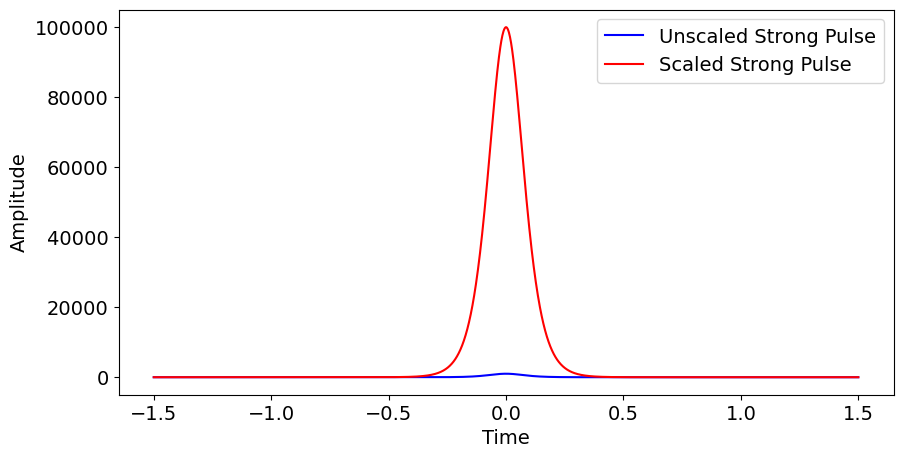

In [7]:
alpha = 10
theta_scaled = theta_strong * alpha
A_strong_scaled = hg_to_time(theta_scaled, hg_basis)

# plot the scaled and unscaled strong pulses
plt.figure(figsize=(10, 5))
plt.plot(t, np.abs(A_strong)**2, label='Unscaled Strong Pulse', color='blue')
plt.plot(t, np.abs(A_strong_scaled)**2, label='Scaled Strong Pulse', color='red')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()

Simulate evolution of scaled pulse, set $N_z$ to specific value

*We know that values of $\alpha=1$ and $N_z=100$ work and since the main acting nonlinear term is $\propto |A^2|dz$ we expect the necessary $N_z$ to scale quadratically with $alpha$, that is $N_z \propto \alpha^2$*


In [10]:
Nz = 5000 #Nz * alpha**2
dz = Lz / Nz
print("Instead of original Nz = 100, we use Nz =", Nz)
A_j_evolution, A_k_evolution = split_step_fourier_xpm(A_weak, A_strong_scaled, dz, Nz, beta2_j, beta2_k, gamma_j, gamma_k, Lt)

Instead of original Nz = 100, we use Nz = 5000


Analyze results

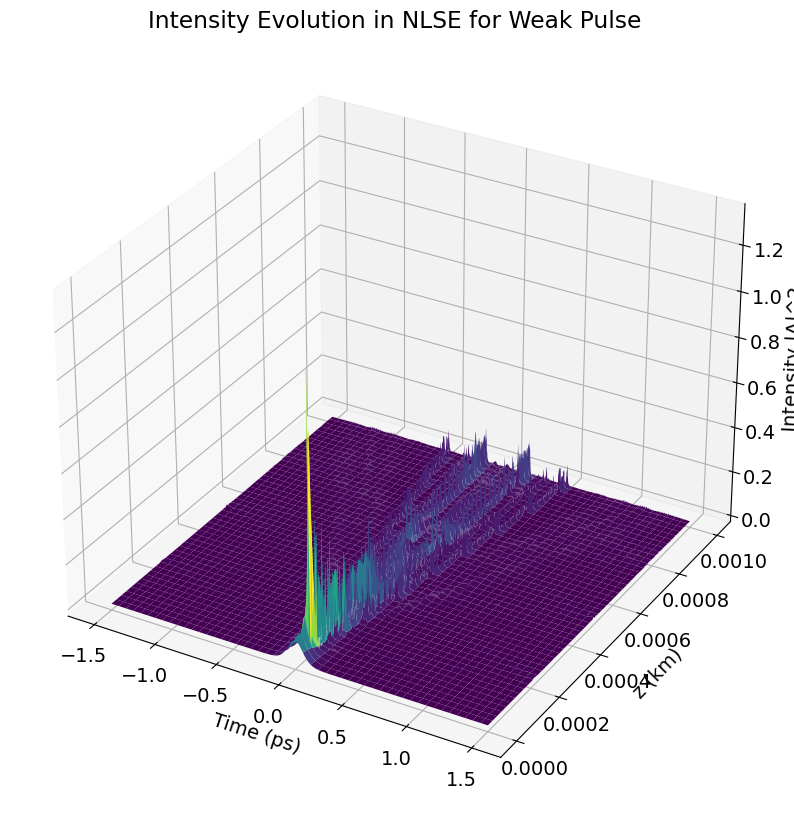

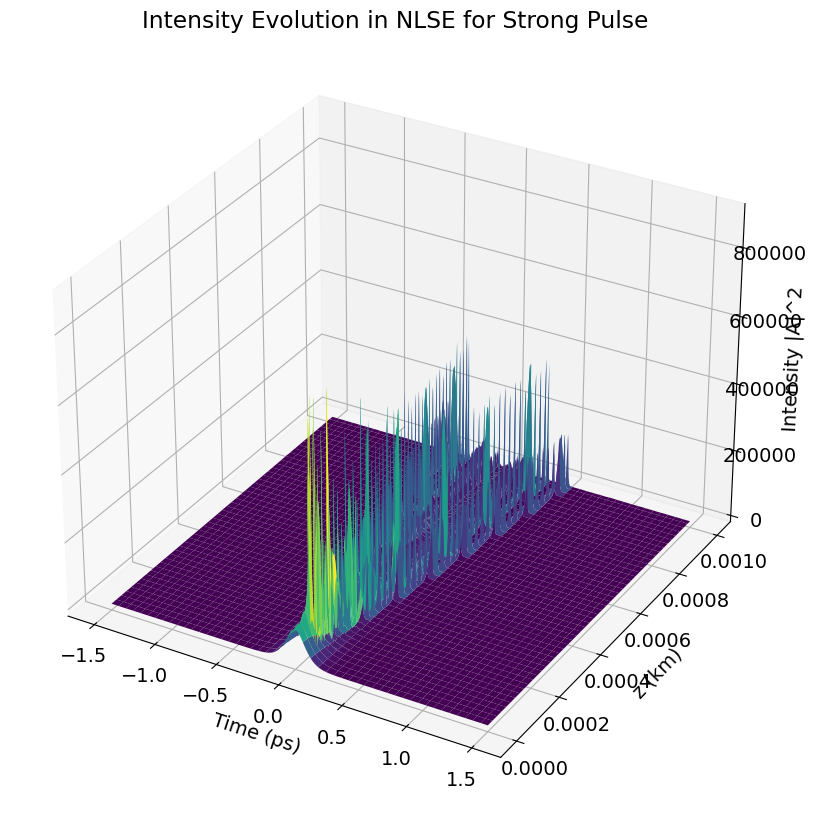

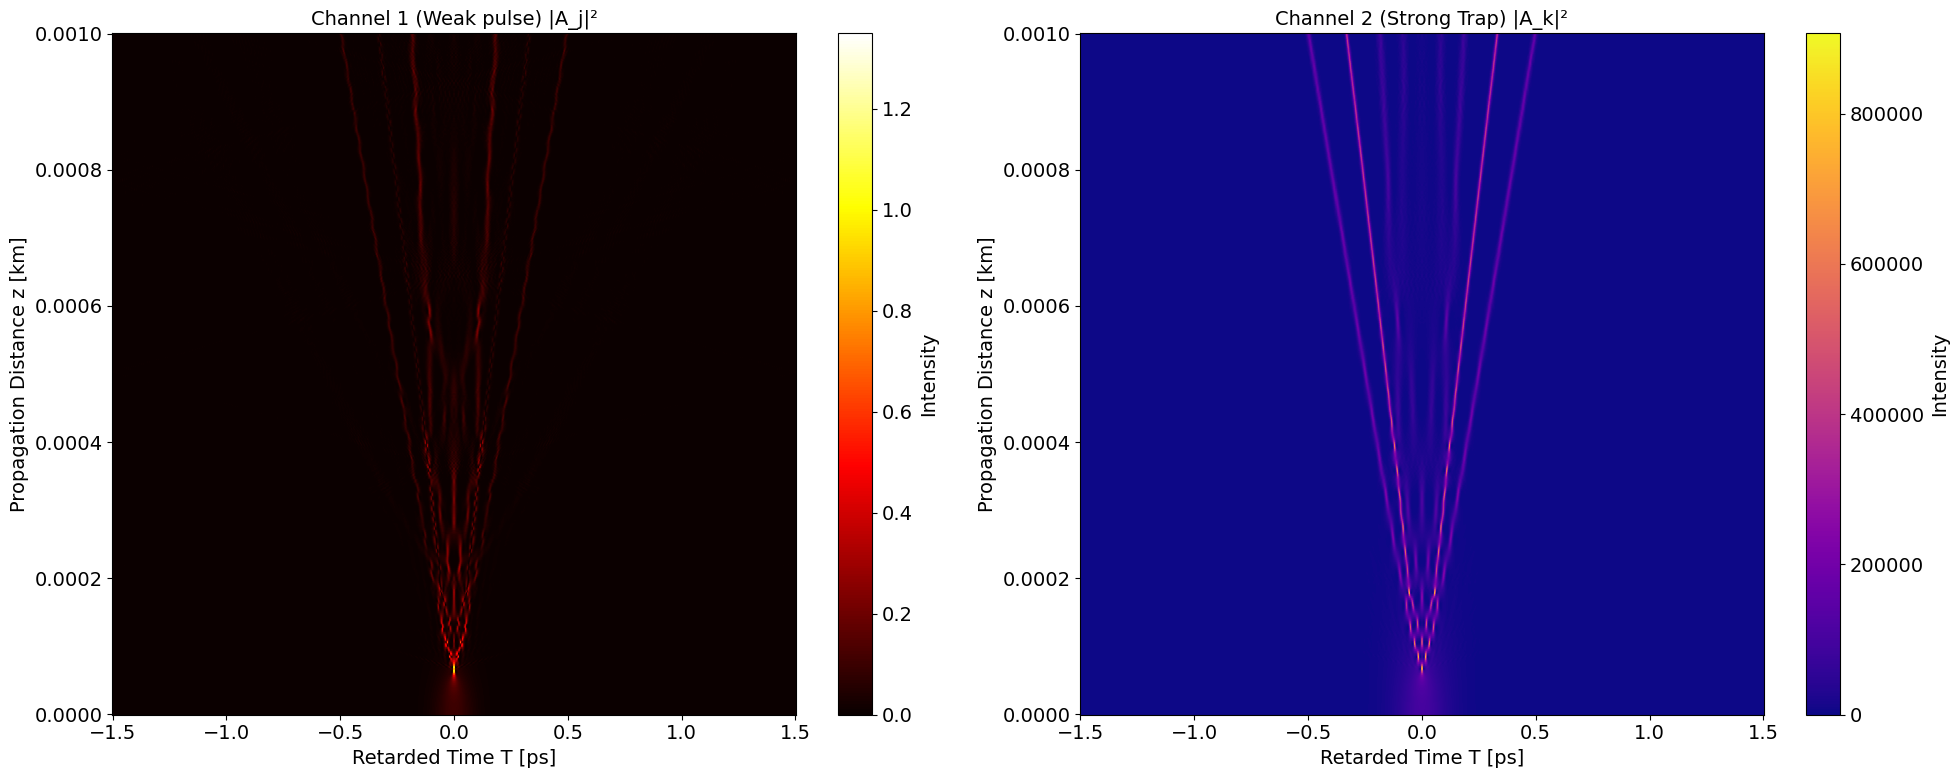

In [9]:
plot_intensity_evolution(A_j_evolution, t, Lz, Nz, wave_name='Weak Pulse')
plot_intensity_evolution(A_k_evolution, t, Lz, Nz, wave_name='Strong Pulse')
plot_cowave_evolution(A_j_evolution.detach().clone(), A_k_evolution.detach().clone(), t, Lz, Nz)